# Documentation — DataSplitter
### Mini ML Library — Data Splitting Module

> **Objective:** Understand, use, and compare the different splitting methods implemented in `DataSplitter`, an alternative built from scratch to `sklearn.model_selection`.

---



## Notebook Outline

| Section | Content |
|---------|---------|
| **1. Introduction** | Why splitting? The 4 methods of `DataSplitter` |
| **2. Concept Clarification** | Train / Val / Test, Data Leakage, Seed, Stratification |
| **3. Presentation of the 4 Methods** | For each method: theory → annotated source code → interactive demo |
| **4. Comparison with scikit-learn** | Functional results (sizes, proportions) + performance measurements (execution time) |
| **4.5 Why no comparison for `temporal_train_test_split`?** | Conceptual difference with `TimeSeriesSplit` |
| **5. Conclusion** | Summary, selection guide, limitations |
| **6. Sources** | Bibliographic references |

---


## 1. Introduction

In Machine Learning, a model learns from data. But to know whether what it has learned is truly useful, it must be tested on data it has **never seen**. This is precisely why we always divide data into multiple parts before starting.

This operation is called **splitting** (or data partitioning). It is one of the most important steps in Machine Learning: done poorly, it can render an entire study incorrect without anyone noticing.

`DataSplitter` provides **4 methods** covering the most common situations:

| Method | Target Situation |
|---|---|
| `train_test_split` | General case, data with no particular order |
| `stratified_train_test_split` | Imbalanced classes (e.g. 90% vs 10%) |
| `temporal_train_test_split` | Time series (data ordered over time) |
| `k_fold_split` | Robust evaluation via cross-validation |


## 2. Concept Clarification

Before going further, it is essential to have a solid understanding of a few key concepts. These are the foundations on which all splitting rests.

---

### 2.1 Train, Validation, and Test: What is each part for?

When dividing a dataset, we generally create two or three subsets. Each has a specific and distinct role.

**Training set (Train)**

This is the part on which the model will learn. It analyzes this data to identify patterns, trends, and relationships between variables. The larger this set, the better the model can learn.

*Analogy:* This is like the lessons and practice exercises a student does throughout the year.

**Validation set (Validation)**

Once the model is trained, it is evaluated on this set to tune its parameters (called hyperparameters). This set allows choosing between several configurations and finding which works best, without touching the test set.

*Analogy:* This is like the mock exams a student takes before the real exam, to adjust their study approach.

**Test set (Test)**

This is the final measurement. This set should be used only once, at the very end, to evaluate the real performance of the model. It simulates completely new data that the model will never see during training.

*Analogy:* This is the final exam. If the student had seen the questions beforehand, their grade would not reflect their true level.

**Typical data splits:**
- Without validation: 80% train, 20% test
- With validation: 60% train, 20% validation, 20% test

---

### 2.2 Data Leakage

Data leakage is one of the most dangerous mistakes in Machine Learning, because it produces **false good results**: the model appears to perform well during training, but fails in production on real data.

**What does it consist of?**

Data leakage occurs when information from the test set "contaminates" training. The model then indirectly learns things it should not know in advance.

**Concrete example:**

Suppose we want to normalize the data (bring them to the same scale) before splitting. To compute this normalization, we use the mean and standard deviation of the ENTIRE dataset, including the test. Result: the model has already seen residual information about the test before even being evaluated on it.

- Bad practice: normalize BEFORE splitting
- Good practice: split BEFORE normalizing, then compute normalization using only the train set

**Another example of leakage:** Using a variable that, in reality, would not be available at prediction time (e.g. using a patient's future outcome to predict their current illness).

Proper splitting is therefore the first line of defense against data leakage.

---

### 2.3 The Seed (Random Seed)

Splitting shuffles data randomly before partitioning. This raises a problem: if we re-run the code, the shuffle will be different, and the splits will differ. Results will therefore not be reproducible.

**The seed** is an integer we fix to "freeze" the randomness. By providing the same seed, NumPy will always generate the same random sequence, and therefore the same split.

This is essential for:
- Reproducing an experiment and obtaining the same results
- Fairly comparing two models (they see exactly the same data)
- Sharing work with other researchers or developers

---

### 2.4 Stratification

**The problem it solves:**

Suppose a dataset where 90% of data belongs to class 0 (e.g. healthy patients) and only 10% to class 1 (e.g. sick patients). We say the classes are **imbalanced**.

If we do a standard random split, the test set may end up with very few, or even no examples from the minority class (class 1). In that case, the model will not be properly evaluated on what is actually the most important case to detect.

**What stratification does:**

Stratification splits the data **class by class**. For each class, it applies the same split ratio (e.g. 80% train, 20% test). Then it merges all these splits. Result: each part (train, test) contains exactly the same class proportions as the original dataset.

**When to use it:** Whenever classes are imbalanced. Examples: bank fraud detection, medical diagnosis of rare diseases, spam detection.


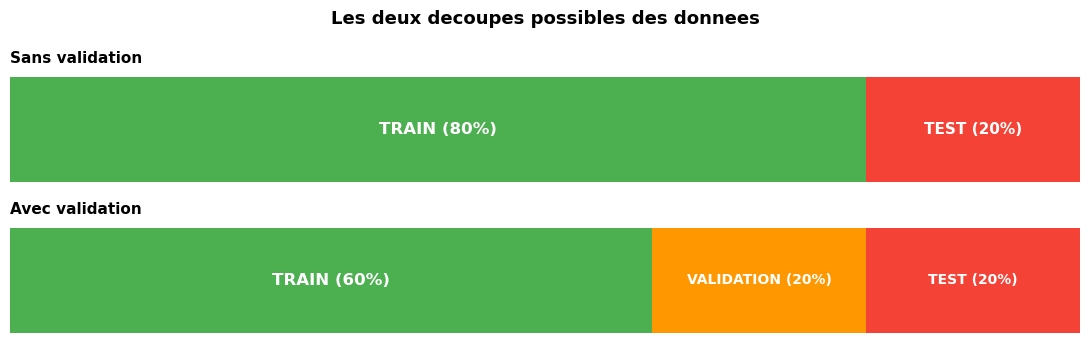

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots: one without validation, one with
fig, axes = plt.subplots(2, 1, figsize=(11, 3.5))

# --- Chart 1: split without validation (train / test) ---
ax = axes[0]
ax.barh(0, 8, left=0, height=0.5, color='#4CAF50')   # 80% train
ax.barh(0, 2, left=8, height=0.5, color='#F44336')   # 20% test
ax.text(4,   0, 'TRAIN (80%)', ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(9,   0, 'TEST (20%)',  ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax.set_xlim(0, 10)
ax.set_title('Without validation', fontsize=11, fontweight='bold', loc='left')
ax.axis('off')

# --- Chart 2: split with validation (train / val / test) ---
ax = axes[1]
ax.barh(0, 6, left=0, height=0.5, color='#4CAF50')   # 60% train
ax.barh(0, 2, left=6, height=0.5, color='#FF9800')   # 20% validation
ax.barh(0, 2, left=8, height=0.5, color='#F44336')   # 20% test
ax.text(3,   0, 'TRAIN (60%)',      ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax.text(7,   0, 'VALIDATION (20%)', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.text(9,   0, 'TEST (20%)',       ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_xlim(0, 10)
ax.set_title('With validation', fontsize=11, fontweight='bold', loc='left')
ax.axis('off')

plt.suptitle('The two possible data splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Reading the visualization above:**

Each bar represented horizontally symbolizes the entire dataset (100% of the data). The colors show how this data is distributed:
- **Green**: the portion used for model training (the largest)
- **Orange**: the portion used for validation (parameter adjustment)
- **Red**: the portion reserved for final testing (real model evaluation)

The split without validation suits simple cases. With validation, the model can be refined more rigorously before evaluation.


In [2]:
import numpy as np

# Without seed: each execution gives a different order
print("Without seed:")
print("  Run 1:", np.random.permutation(10)[:6])  # first 6 indices after shuffle
print("  Run 2:", np.random.permutation(10)[:6])  # different from run 1

# With seed: the result is always identical
print()
print("With seed=42:")
np.random.seed(42)
print("  Run 1:", np.random.permutation(10)[:6])  # always the same
np.random.seed(42)                                  # reset seed to same point
print("  Run 2:", np.random.permutation(10)[:6])  # identical to run 1


Sans seed :
  Run 1 : [2 3 1 6 4 8]
  Run 2 : [4 8 0 5 9 6]

Avec seed=42 :
  Run 1 : [8 1 5 0 7 2]
  Run 2 : [8 1 5 0 7 2]


**Reading the result:**

The two "Without seed" lines will display different index orders at each execution. On the other hand, the two "With seed=42" lines will always display exactly the same order, regardless of when or on which machine the code is executed.

---

### 2.4 Stratification

**The problem it solves:**

Suppose a dataset where 90% of data belongs to class 0 (e.g. healthy patients) and only 10% to class 1 (e.g. sick patients). We say the classes are **imbalanced**.

If we do a standard random split, the test set may contain very few, or even no, examples from the minority class (class 1). In that case, the model will not be properly evaluated on what is actually the most important case to detect.

**What stratification does:**

Stratification splits the data **class by class**. For each class, it applies the same split ratio (e.g. 80% train, 20% test). Then it merges all these splits. Result: each part (train, test) contains exactly the same class proportions as the original dataset.

**When to use it:** Whenever classes are imbalanced. Examples: bank fraud detection, medical diagnosis of rare diseases, spam detection.


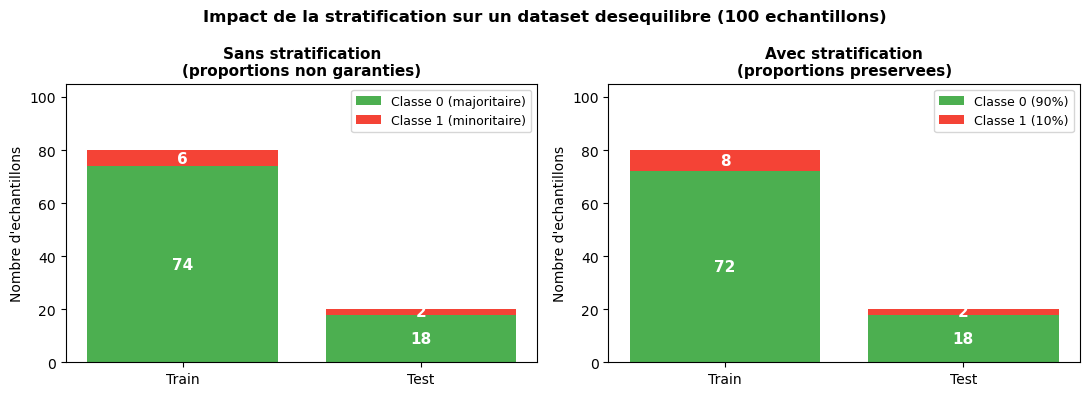

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Figure configuration: two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left chart: without stratification ──────────────────────────────────────
ax = axes[0]

# In a random split on an imbalanced dataset (100 total, 90% class 0, 10% class 1),
# the test may be dominated by class 0 and contain almost no class 1
train_cls0_nosplit = 74   # class 0 in train
train_cls1_nosplit = 6    # class 1 in train (almost nothing)
test_cls0_nosplit  = 18   # class 0 in test
test_cls1_nosplit  = 2    # class 1 in test (too few to be reliable)

ax.bar(['Train', 'Test'],
       [train_cls0_nosplit, test_cls0_nosplit],
       color='#4CAF50', label='Class 0 (majority)')
ax.bar(['Train', 'Test'],
       [train_cls1_nosplit, test_cls1_nosplit],
       bottom=[train_cls0_nosplit, test_cls0_nosplit],
       color='#F44336', label='Class 1 (minority)')

ax.set_title('Without stratification\n(proportions not guaranteed)', fontsize=11, fontweight='bold')
ax.set_ylabel("Number of samples")
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

# Annotate proportions inside each bar
ax.text(0, train_cls0_nosplit/2, f'{train_cls0_nosplit}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(0, train_cls0_nosplit + train_cls1_nosplit/2, f'{train_cls1_nosplit}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(1, test_cls0_nosplit/2, f'{test_cls0_nosplit}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(1, test_cls0_nosplit + test_cls1_nosplit/2, f'{test_cls1_nosplit}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# ── Right chart: with stratification ───────────────────────────────────────
ax = axes[1]

# With stratification, the 90/10 proportions are preserved in each split
train_cls0_strat = 72   # 90% of 80 = 72
train_cls1_strat = 8    # 10% of 80 = 8
test_cls0_strat  = 18   # 90% of 20 = 18
test_cls1_strat  = 2    # 10% of 20 = 2

ax.bar(['Train', 'Test'],
       [train_cls0_strat, test_cls0_strat],
       color='#4CAF50', label='Class 0 (90%)')
ax.bar(['Train', 'Test'],
       [train_cls1_strat, test_cls1_strat],
       bottom=[train_cls0_strat, test_cls0_strat],
       color='#F44336', label='Class 1 (10%)')

ax.set_title('With stratification\n(proportions preserved)', fontsize=11, fontweight='bold')
ax.set_ylabel("Number of samples")
ax.legend(fontsize=9)
ax.set_ylim(0, 105)

ax.text(0, train_cls0_strat/2, f'{train_cls0_strat}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(0, train_cls0_strat + train_cls1_strat/2, f'{train_cls1_strat}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(1, test_cls0_strat/2, f'{test_cls0_strat}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax.text(1, test_cls0_strat + test_cls1_strat/2, f'{test_cls1_strat}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')

plt.suptitle('Impact of stratification on an imbalanced dataset (100 samples)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Reading the visualization:**

Each bar represents the composition of the train or test set. Green represents the majority class (class 0), red the minority class (class 1).

- **Left chart (without stratification):** Class 1 is represented by only 2 examples in the test set. That is too few for a reliable evaluation. The model may appear to perform well by simply ignoring class 1.
- **Right chart (with stratification):** The 90%/10% proportions are exactly preserved in both train and test. The evaluation will be representative of reality.


## 3. Presentation of the 4 Implemented Methods

### Imports and Demo Data



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil, os

# Copy splitting.py to the current directory so it can be imported
if not os.path.exists('splitting.py'):
    shutil.copy('/mnt/user-data/uploads/splitting.py', 'splitting.py')

from splitting import DataSplitter

# ── Create demo datasets ─────────────────────────────────────────────────────

np.random.seed(42)
n = 200  # total number of samples

# Standard dataset: 3 numerical features
X = pd.DataFrame({
    'feature_1': np.random.randn(n),
    'feature_2': np.random.randn(n),
    'feature_3': np.random.rand(n) * 100
})

# Balanced labels (3 classes)
y_balanced = pd.Series(np.random.randint(0, 3, n))

# Imbalanced labels: only 10% class 1 (rare case like fraud)
y_imbalanced = pd.Series(np.where(np.random.rand(n) < 0.1, 1, 0))

# Temporal dataset: index = dates (chronological series)
dates = pd.date_range('2022-01-01', periods=n, freq='D')
X_temporal = X.copy()
X_temporal.index = dates
y_temporal = pd.Series(np.cumsum(np.random.randn(n)), index=dates)  # cumulative series

print(f"Main dataset       : {n} samples, {X.shape[1]} features")
print(f"Balanced labels    : {dict(y_balanced.value_counts().sort_index())}")
print(f"Imbalanced labels  : {dict(y_imbalanced.value_counts().sort_index())}")
print(f"Time period        : {dates[0].date()} to {dates[-1].date()}")


Dataset principal      : 200 echantillons, 3 features
Labels equilibres      : {0: np.int64(69), 1: np.int64(60), 2: np.int64(71)}
Labels desequilibres   : {0: np.int64(175), 1: np.int64(25)}
Periode temporelle     : 2022-01-01 a 2022-07-19


---

### 3.1 `train_test_split` — Simple Random Split

**What does it consist of?**

This is the most basic and widely used method. It randomly shuffles the data, then splits it according to the requested proportions. It does not account for classes or the order of the data.

**How it works (reading the code):**

1. We create an index array `[0, 1, 2, ..., n-1]` representing each row of the dataset
2. We shuffle these indices randomly (`np.random.shuffle`)
3. We take the first `test_size * n` indices for the test set, the rest for train
4. If `val_set=True`, we split the train again to create a validation set

**When to use it:**
- Data has no particular order (not a time series)
- Classes are relatively balanced
- A simple and fast evaluation is needed

**When not to use it:**
- If classes are imbalanced (prefer `stratified_train_test_split`)
- If data is ordered over time (prefer `temporal_train_test_split`)


#### Source Code Walkthrough — `train_test_split`


In [5]:
# ── Implementation of train_test_split ─────────────────────────────────────
# Goal: shuffle data randomly, then split into two
# (or three) parts according to the requested proportions.

def train_test_split(self, X, y=None, test_size=0.2, val_set=False, val_size=0.2):

    # ── Step 1: create and shuffle indices ──────────────────────────────────
    # We do not move the data itself: we first generate an integer array
    # [0, 1, 2, ..., n-1] representing the row positions.
    # np.random.shuffle() shuffles them IN PLACE (no copy), based on
    # the seed set in __init__ → always identical result for the same seed.
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    # ── Step 2: compute the test / train boundary ────────────────────────────
    # int() truncates downward: if test_size=0.2 and n=201, we get 40
    # (not 40.2). The first shuffled indices go to test, the rest to train.
    test_end  = int(test_size * len(X))
    test_idx  = indices[:test_end]   # 20% → test
    train_idx = indices[test_end:]   # 80% → train

    # ── Step 3a: return without validation ──────────────────────────────────
    # .iloc[] selects rows by integer position (not by label).
    # This is necessary because indices can be in any order after shuffling.
    if not val_set:
        if y is None:
            return X.iloc[train_idx], X.iloc[test_idx]
        else:
            return (X.iloc[train_idx], X.iloc[test_idx],
                    y.iloc[train_idx], y.iloc[test_idx])

    # ── Step 3b: return with validation ─────────────────────────────────────
    # We take val_size * len(train_idx) indices from the head of train
    # to build the validation set. The actual train is what remains.
    else:
        val_split     = int(val_size * len(train_idx))
        val_idx       = train_idx[:val_split]
        new_train_idx = train_idx[val_split:]

        if y is None:
            return (X.iloc[new_train_idx], X.iloc[val_idx], X.iloc[test_idx])
        else:
            return (X.iloc[new_train_idx], X.iloc[val_idx], X.iloc[test_idx],
                    y.iloc[new_train_idx], y.iloc[val_idx], y.iloc[test_idx])


**Key takeaways:**

- **Work on indices, not the data itself**: moving integers is much faster than copying entire DataFrames. `.iloc[]` performs the selection in a single operation at the end.
- **`int()` rather than `round()`**: we intentionally truncate to never exceed `n` observations. A difference of one or two samples has no practical impact.
- **The seed acts from the constructor** (`np.random.seed(seed)` in `__init__`), so all subsequent calls to `np.random.shuffle` are deterministic for a given `DataSplitter` object.
- **`y` is optional**: if there is no target variable (e.g. autoencoder, clustering), `X` can be split alone.


In [6]:
# ── Instantiate DataSplitter with a fixed seed ──────────────────────────────
splitter = DataSplitter(seed=42)  # seed=42 guarantees reproducible results

# ── Simple split: train + test only ─────────────────────────────────────────
# test_size=0.2 means: 20% of the data goes to test, 80% to train
X_train, X_test, y_train, y_test = splitter.train_test_split(
    X, y_balanced, test_size=0.2
)

print("=== Simple Split (without validation) ===")
print(f"Train : {len(X_train)} samples ({len(X_train)/n:.0%})")
print(f"Test  : {len(X_test)}  samples ({len(X_test)/n:.0%})")

# ── Split with validation ────────────────────────────────────────────────────
# val_size=0.2 means: 20% of the remaining train becomes validation
splitter2 = DataSplitter(seed=42)
X_tr, X_val, X_te, y_tr, y_val, y_te = splitter2.train_test_split(
    X, y_balanced,
    test_size=0.2,   # 20% for test
    val_set=True,    # enable validation
    val_size=0.2     # 20% of train -> validation (i.e. ~16% of total)
)

print("\n=== Split with validation ===")
print(f"Train      : {len(X_tr)}  samples ({len(X_tr)/n:.0%})")
print(f"Validation : {len(X_val)} samples ({len(X_val)/n:.0%})")
print(f"Test       : {len(X_te)}  samples ({len(X_te)/n:.0%})")


=== Split simple (sans validation) ===
Train : 160 echantillons (80%)
Test  : 40  echantillons (20%)

=== Split avec validation ===
Train      : 128  echantillons (64%)
Validation : 32 echantillons (16%)
Test       : 40  echantillons (20%)


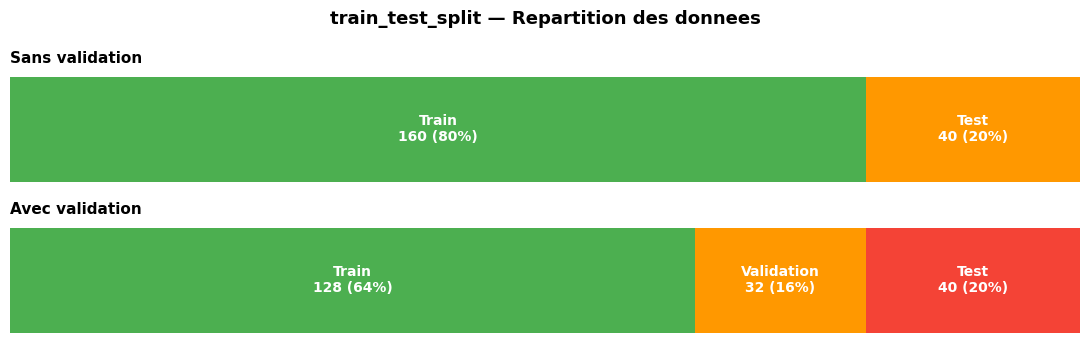

In [7]:
# ── Visualization of the two splits ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 3.5))

# Data for each chart: (labels, sizes, title)
splits_info = [
    (['Train', 'Test'], [len(X_train), len(X_test)], 'Without validation'),
    (['Train', 'Validation', 'Test'], [len(X_tr), len(X_val), len(X_te)], 'With validation'),
]

# Colors associated with each part
palette = ['#4CAF50', '#FF9800', '#F44336']

for ax, (labels, sizes, title) in zip(axes, splits_info):
    left = 0  # starting point of the next bar
    for i, (lbl, sz) in enumerate(zip(labels, sizes)):
        ax.barh(0, sz, left=left, height=0.5, color=palette[i])
        ax.text(left + sz/2, 0,
                f'{lbl}\n{sz} ({sz/n:.0%})',
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        left += sz  # shift starting point for next bar
    ax.set_xlim(0, n)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.axis('off')

plt.suptitle('train_test_split — Data Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Reading the visualization:**

Each horizontal bar represents the entire dataset (200 samples). The colored segments show how many samples go into each part. We can clearly see that:
- Without validation: the train receives 160 examples (80%), the test 40 (20%)
- With validation: the train is reduced to about 128, validation takes ~32, and the test keeps 40


---

### 3.2 `stratified_train_test_split` — Stratified Split

**What does it consist of?**

Instead of treating all the data together, stratification first divides the dataset **by class**. For each class separately, it applies the same split ratio. Then it merges all the train parts together and all the test parts together.

**How it works (reading the code):**

1. We retrieve the list of all unique classes (`np.unique(y)`)
2. For each class, we retrieve the corresponding indices
3. We shuffle those indices, then split them according to `test_size`
4. We accumulate the train and test indices of each class into two lists
5. At the end, we merge everything: the train indices from all classes form the final train set

**When to use it:**
- Imbalanced dataset: one class is much rarer than the others
- Binary or multi-class classification problems with unequal proportions
- Examples: fraud detection, medical diagnosis, fault detection

**When not to use it:**
- If classes are already well balanced (the simple split is sufficient)
- For regression problems (no classes to stratify)


#### Source Code Walkthrough — `stratified_train_test_split`


In [8]:
# ── Implementation of stratified_train_test_split ──────────────────────────
# Goal: ensure that each class is represented in the same
# proportions in both train AND test, regardless of its frequency.

def stratified_train_test_split(self, X, y, test_size=0.2, val_set=False, val_size=0.2):

    # ── Step 1: retrieve classes present in y ───────────────────────────────
    # np.unique() returns the distinct values sorted.
    # We then iterate over each class separately: this is the core of
    # stratification. Each class is split independently.
    classes = np.unique(y)
    train_idx, val_idx, test_idx = [], [], []

    for cls in classes:

        # ── Step 2: indices of the current class ────────────────────────────
        # np.where(y == cls)[0] returns the positions of rows belonging
        # to this class. We shuffle them before splitting.
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)
        n = len(cls_indices)

        # ── Step 3: test / train split for this class ────────────────────────
        # We apply the same test_size ratio to each class.
        # Result: if the class represents 10% of the dataset, it will also
        # represent ~10% of the test and ~10% of the train.
        test_end  = int(test_size * n)
        cls_test  = cls_indices[:test_end]
        cls_train = cls_indices[test_end:]

        # ── Step 4 (optional): extract validation ────────────────────────────
        if val_set:
            val_split = int(val_size * len(cls_train))
            cls_val   = cls_train[:val_split]
            cls_train = cls_train[val_split:]
            val_idx.extend(cls_val)

        # ── Step 5: accumulate in global lists ──────────────────────────────
        # .extend() adds the indices of the current class to the lists
        # already built for previous classes.
        test_idx.extend(cls_test)
        train_idx.extend(cls_train)

    # ── Final return ─────────────────────────────────────────────────────────
    if not val_set:
        return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
    else:
        return (X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx],
                y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx])


**Key takeaways:**

- **Loop by class**: this is the central idea. We do not shuffle everything then cut — we cut *within* each class, then reassemble. This mechanically preserves proportions.
- **`np.where(y == cls)[0]`**: the `[0]` is essential because `np.where` returns a tuple; we extract the first element (the index array).
- **`.extend()` vs `.append()`**: `.extend()` "flattens" the list by adding each element individually, whereas `.append()` would add the entire array as a single nested element.
- **Edge case**: if a class has only 1 or 2 examples, `int(test_size * 1) = 0` — it will not appear in the test set. This is a known behavior; sklearn raises an error in this case.


In [9]:
# ── Stratified split on the imbalanced dataset ──────────────────────────────
# y_imbalanced contains 90% of 0 and 10% of 1 (rare class)
splitter3 = DataSplitter(seed=42)

X_tr_s, X_te_s, y_tr_s, y_te_s = splitter3.stratified_train_test_split(
    X, y_imbalanced, test_size=0.2  # 20% for test, respecting proportions
)

# Utility function: computes the percentage of a class in a series
def pct_classe(y, classe=1):
    return (y == classe).sum() / len(y)

print("=== Stratified Split ===")
print(f"Train : {len(X_tr_s)} samples")
print(f"Test  : {len(X_te_s)} samples")
print()
print("Proportion of class 1 (rare):")
print(f"  Original : {pct_classe(y_imbalanced):.1%}")   # reference
print(f"  Train    : {pct_classe(y_tr_s):.1%}")          # should be close to original
print(f"  Test     : {pct_classe(y_te_s):.1%}")          # should also be close


=== Stratified Split ===
Train : 160 echantillons
Test  : 40 echantillons

Proportion de la classe 1 (rare) :
  Original : 12.5%
  Train    : 12.5%
  Test     : 12.5%


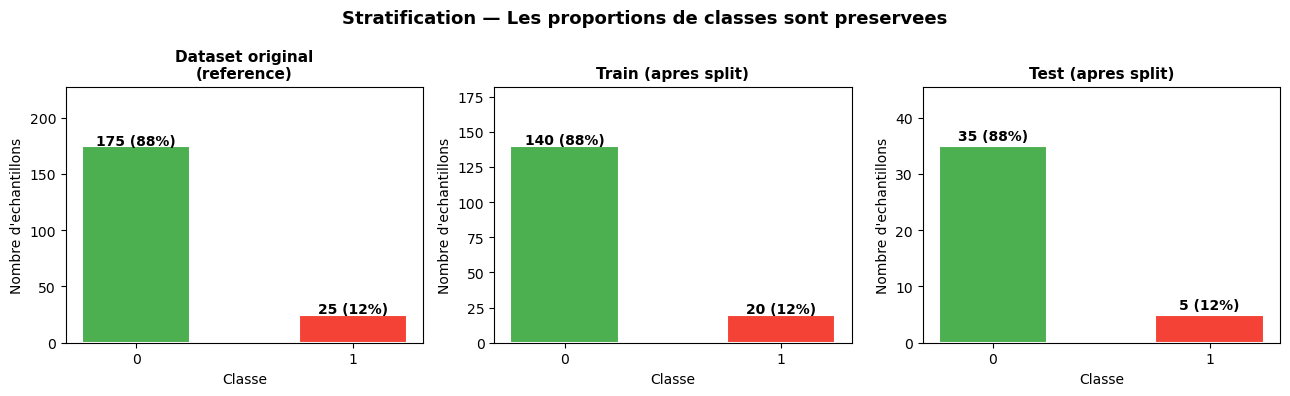

In [10]:
# ── Visualization: distributions before and after split ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# The three sets to compare
ensembles = [
    (y_imbalanced, 'Original dataset\n(reference)'),
    (y_tr_s,       'Train (after split)'),
    (y_te_s,       'Test (after split)'),
]

for ax, (y_data, titre) in zip(axes, ensembles):
    counts = y_data.value_counts().sort_index()
    colors = ['#4CAF50', '#F44336']  # green = class 0, red = class 1

    bars = ax.bar(
        counts.index.astype(str),  # 0 and 1 on x-axis
        counts.values,
        color=colors,
        edgecolor='white',
        linewidth=1.5,
        width=0.5
    )

    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel("Number of samples")
    ax.set_ylim(0, max(counts.values) * 1.3)

    # Show count and percentage above each bar
    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 1,
            f'{val} ({val/len(y_data):.0%})',
            ha='center', fontsize=10, fontweight='bold'
        )

plt.suptitle('Stratification — Class proportions are preserved', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Reading the visualization:**

The three charts represent the distribution of classes (0 and 1) in the original dataset, then in the train and test sets after stratification.

We observe that the percentages shown above the bars are nearly identical across all three charts: approximately 90% class 0 and 10% class 1 everywhere. This is precisely the goal of stratification: each part of the split is a faithful mirror of the original dataset in terms of class proportions.


---

### 3.3 `temporal_train_test_split` — Temporal Split

**What does it consist of?**

For data ordered over time (time series), the standard split does not work: mixing future data with past data would create a severe form of data leakage. The temporal split preserves chronological order by reserving the **most recent** data for the test set.

**How it works (reading the code):**

1. We do NOT shuffle the data (no shuffle)
2. We compute the boundary: the last `test_size * n` samples go to the test set
3. Everything before this boundary constitutes the train set
4. If `val_set=True`, the last samples of the train set become the validation set

**Why this matters:**

Imagine we want to predict tomorrow's sales. If we train the model on data that includes points from after tomorrow, it "knows" what happened and is cheating. The temporal boundary prevents this type of leakage.

**When to use it:**
- Time series: stock prices, weather, sales, web traffic
- Any situation where data has a chronological order that must be preserved
- Predictions into the future

**When not to use it:**
- If data has no temporal order (previous methods apply)


#### Source Code Walkthrough — `temporal_train_test_split`


In [11]:
# ── Implementation of temporal_train_test_split ─────────────────────────────
# Goal: split a time series while respecting chronological order.
# NO shuffling is performed: the most recent data goes to test,
# the oldest to train. This is the only way to avoid data leakage
# on temporal data.

def temporal_train_test_split(self, X, y=None, test_size=0.2, val_set=False, val_size=0.2):

    n_samples = len(X)

    # ── Step 1: compute the test boundary ────────────────────────────────────
    # test_end = number of observations reserved for test (the most recent).
    # We use negative slicing: X.iloc[-test_end:] takes the LAST rows.
    # X.iloc[:-test_end] takes everything before.
    test_end = int(test_size * n_samples)

    X_test  = X.iloc[-test_end:]    # ← recent data = test
    X_train = X.iloc[:-test_end]    # ← older data = train

    # ── Step 2: handle y ─────────────────────────────────────────────────────
    # Same split applied to the target if provided.
    if y is not None:
        y_test  = y.iloc[-test_end:]
        y_train = y.iloc[:-test_end]

    # ── Step 3a: return without validation ───────────────────────────────────
    if not val_set:
        if y is None:
            return X_train, X_test
        else:
            return X_train, X_test, y_train, y_test

    # ── Step 3b: return with validation ──────────────────────────────────────
    # Validation is taken from the END of train (most recent training data),
    # in order to respect chronological order: train < val < test.
    else:
        val_end = int(val_size * len(X_train))
        X_val   = X_train.iloc[-val_end:]    # end of train → validation
        X_train = X_train.iloc[:-val_end]    # beginning of train → actual train

        if y is None:
            return X_train, X_val, X_test
        else:
            y_val   = y_train.iloc[-val_end:]
            y_train = y_train.iloc[:-val_end]
            return X_train, X_val, X_test, y_train, y_val, y_test


**Key takeaways:**

- **No `np.random.shuffle`**: this is the fundamental difference from the two previous methods. Shuffling temporal data would cause data leakage (the model would see the future during training).
- **Negative slicing `iloc[-n:]`**: in Python, `-n` means "starting from the n-th position from the end". This is the most natural way to extract the last observations of a series.
- **Order train < val < test**: in the case with validation, we take the end of the train for validation — not the beginning. This preserves chronological order: the oldest data trains, the intermediate validates, and the most recent tests.
- **No seed needed**: since there is no randomization, the result is always identical regardless of configuration.


In [12]:
# ── Temporal split: test = most recent data ─────────────────────────────────
splitter4 = DataSplitter()  # no seed needed: no random shuffle here

X_tr_t, X_te_t, y_tr_t, y_te_t = splitter4.temporal_train_test_split(
    X_temporal, y_temporal, test_size=0.2  # the most recent 20% of data -> test
)

print("=== Temporal Split ===")
print(f"Train : {len(X_tr_t)} samples")
print(f"  Period: {X_tr_t.index[0].date()} -> {X_tr_t.index[-1].date()}")
print()
print(f"Test  : {len(X_te_t)} samples")
print(f"  Period: {X_te_t.index[0].date()} -> {X_te_t.index[-1].date()}")
print()
# Key verification: no train date should exceed the first test date
print(f"Check: last train date < first test date? {X_tr_t.index[-1] < X_te_t.index[0]}")


=== Temporal Split ===
Train : 160 echantillons
  Periode : 2022-01-01 -> 2022-06-09

Test  : 40 echantillons
  Periode : 2022-06-10 -> 2022-07-19

Verification : derniere date train < premiere date test ? True


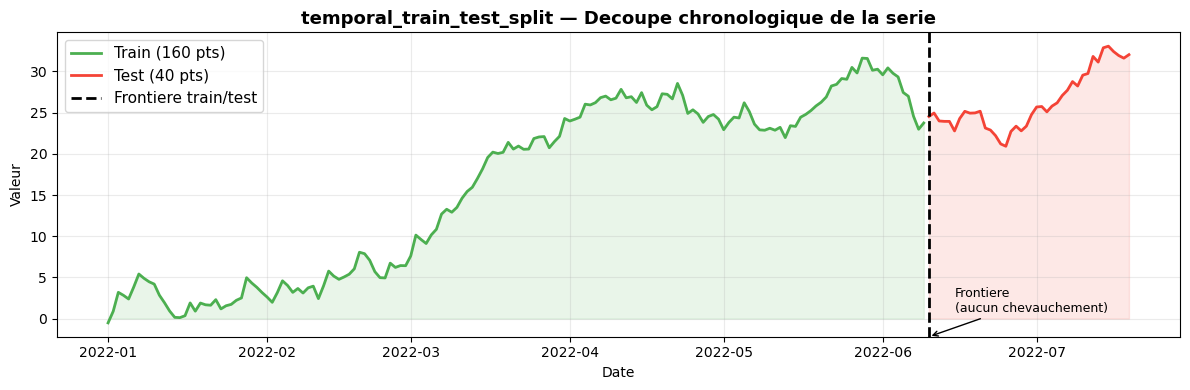

In [13]:
# ── Visualization: time series with the train/test boundary ─────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Plot the train curve in green
ax.plot(y_tr_t.index, y_tr_t.values,
        color='#4CAF50', linewidth=2, label=f'Train ({len(y_tr_t)} pts)')

# Plot the test curve in red
ax.plot(y_te_t.index, y_te_t.values,
        color='#F44336', linewidth=2, label=f'Test ({len(y_te_t)} pts)')

# Vertical line marking the train/test boundary
ax.axvline(x=X_te_t.index[0],
           color='black', linestyle='--', linewidth=2,
           label='Train/test boundary')

# Colored area to better distinguish the two parts
ax.fill_between(y_tr_t.index, y_tr_t.values, alpha=0.12, color='#4CAF50')
ax.fill_between(y_te_t.index, y_te_t.values, alpha=0.12, color='#F44336')

# Boundary annotation
ax.annotate('Boundary\n(no overlap)',
            xy=(X_te_t.index[0], ax.get_ylim()[0]),
            xytext=(X_te_t.index[5], ax.get_ylim()[0] + 3),
            fontsize=9, color='black',
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title('temporal_train_test_split — Chronological split of the series', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


**Reading the visualization:**

The green curve represents the training period (the oldest data), and the red curve the test period (the most recent data). The black dashed line marks the exact boundary between the two.

We observe that there is no overlap between the two parts: all training dates are earlier than all test dates. This is precisely what we want to avoid temporal data leakage.


---

### 3.4 `k_fold_split` — Cross-Validation (K-Fold)

**What does it consist of?**

K-Fold is a more advanced evaluation technique. Instead of making a single split, we divide the data into `k` equally sized groups (called "folds"). We then perform `k` rounds of training/evaluation:
- In each round, a different fold is used as the test set
- The remaining `k-1` folds are used as the train set
- We obtain `k` performance scores, of which we compute the average

**How it works (reading the code):**

1. We shuffle the indices randomly
2. We compute the size of each fold: `fold_size = len(X) // k`
3. For each fold `i`, indices `[i * fold_size : (i+1) * fold_size]` form the test set
4. All other indices form the train set
5. We repeat for each value of `i` from 0 to k-1

**Major advantage:** Each sample is used exactly once as a test and `k-1` times as training. We use 100% of available data, which gives a much more stable and reliable evaluation.

**When to use it:**
- Limited dataset size (we cannot afford to "lose" data in the test set)
- Rigorous model evaluation before deployment
- Fair comparison of multiple different models

**When not to use it:**
- Very large datasets (K-Fold is slow because we train k models)
- Time series (prefer `temporal_train_test_split`)


#### Source Code Walkthrough — `k_fold_split`


In [14]:
# ── Implementation of k_fold_split ──────────────────────────────────────────
# Goal: generate k (train, test) pairs by "rotating" the test fold
# over the full length of the dataset. Each observation is used exactly
# once as test and k-1 times as training.

def k_fold_split(self, X, y=None, k=5):

    # ── Step 1: initial shuffle of indices ───────────────────────────────────
    # We shuffle once, before creating all folds.
    # This avoids any bias related to the original order of the data.
    indices  = np.arange(len(X))
    np.random.shuffle(indices)

    # ── Step 2: fold size ────────────────────────────────────────────────────
    # Integer division: if n=201 and k=5, fold_size=40 (not 40.2).
    # Surplus sample(s) are ignored — same behavior as sklearn KFold by default.
    fold_size = len(X) // k
    folds = []

    # ── Step 3: build the k (train, test) pairs ──────────────────────────────
    for i in range(k):

        # The test fold = the slice [i*fold_size : (i+1)*fold_size]
        # At each iteration i, this window shifts one fold to the right.
        test_idx  = indices[i * fold_size : (i + 1) * fold_size]

        # The train = everything BEFORE + everything AFTER the test fold.
        # np.concatenate() merges two arrays into one.
        train_idx = np.concatenate([
            indices[:i * fold_size],           # indices before the test fold
            indices[(i + 1) * fold_size:]      # indices after the test fold
        ])

        # ── Step 4: build DataFrames and accumulate ──────────────────────────
        if y is None:
            folds.append((X.iloc[train_idx], X.iloc[test_idx]))
        else:
            folds.append((X.iloc[train_idx], X.iloc[test_idx],
                          y.iloc[train_idx], y.iloc[test_idx]))

    # Returns a list of k tuples, ready to be iterated in a loop.
    return folds


**Key takeaways:**

- **Single shuffle for all folds**: we shuffle the indices once at the beginning, then slice them into regular chunks. If we reshuffled at each fold, the same observations could end up in multiple test folds.
- **`np.concatenate([before, after])`**: this is the central trick of K-Fold. The train set is always the "complement" of the test — everything except slice `i`.
- **Integer division `//`**: surplus observations (if `n` is not divisible by `k`) are simply ignored. For `n=201, k=5`: 200 observations used, 1 ignored.
- **List of tuples returned**: unlike other methods that return splits directly, `k_fold_split` returns a *list*. Use it with a loop: `for X_train, X_test, y_train, y_test in folds:`.
- **No stratified K-Fold here**: if classes are imbalanced, some folds might lack minority examples. For this case, sklearn offers `StratifiedKFold`.


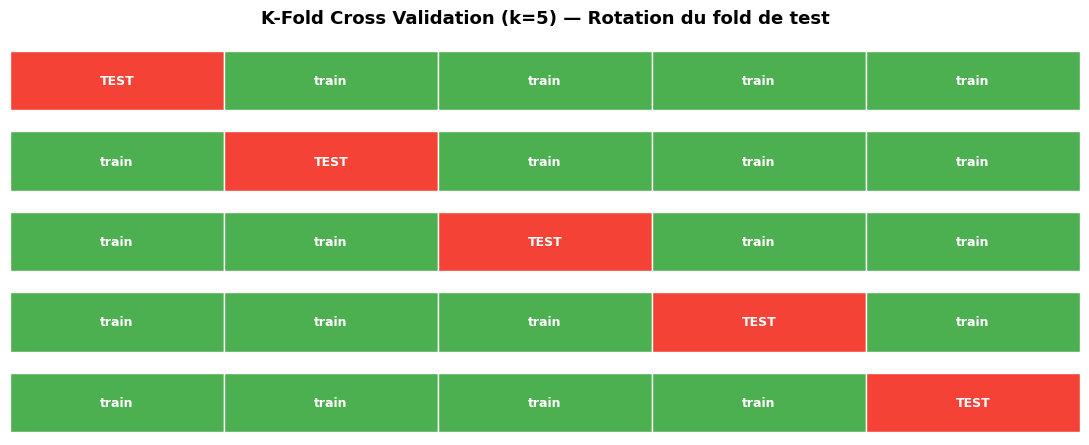

In [15]:
# ── Visual diagram of K-Fold before execution ───────────────────────────────
k = 5
n_total = 200
fold_size = n_total // k  # size of each fold

fig, axes = plt.subplots(k, 1, figsize=(11, 4.5))
fig.suptitle(f'K-Fold Cross Validation (k={k}) — Rotation of the test fold', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes):
    left = 0
    for j in range(k):
        # Current fold (j == i) is red (test), others are green (train)
        color = '#F44336' if j == i else '#4CAF50'
        label_txt = 'TEST' if j == i else 'train'
        ax.barh(0, fold_size, left=left, height=0.55, color=color, edgecolor='white')
        ax.text(left + fold_size / 2, 0, label_txt,
                ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        left += fold_size

    ax.set_xlim(0, n_total)
    ax.set_ylabel(f'Round {i+1}', rotation=0, labelpad=45, va='center', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [16]:
# ── Apply K-Fold and display fold sizes ──────────────────────────────────────
splitter5 = DataSplitter(seed=42)

# k_fold_split returns a list of k tuples (X_train, X_test, y_train, y_test)
folds = splitter5.k_fold_split(X, y_balanced, k=5)

print(f"Number of folds generated: {len(folds)}")
print()
print(f"{'Round':>7} | {'Train':>8} | {'Test':>6} | {'Test ratio':>10}")
print("-" * 42)

for i, (X_tr_f, X_te_f, y_tr_f, y_te_f) in enumerate(folds):
    # At each round, display the size of train and test
    print(f"  Fold {i+1}  | {len(X_tr_f):>8} | {len(X_te_f):>6} | {len(X_te_f)/n:>9.0%}")

print()
print("Each sample appears exactly 1 time in the test set.")


Nombre de folds generes : 5

  Round |    Train |   Test | Ratio test
------------------------------------------
  Fold 1  |      160 |     40 |       20%
  Fold 2  |      160 |     40 |       20%
  Fold 3  |      160 |     40 |       20%
  Fold 4  |      160 |     40 |       20%
  Fold 5  |      160 |     40 |       20%

Chaque echantillon apparait exactement 1 fois dans le test.


## 4. Comparison with scikit-learn

Let us compare the results of our `DataSplitter` with the equivalents in `sklearn.model_selection` to verify consistency and identify differences.


In [17]:
# Utility function to compute % of class 1
def pct_classe(y):
    return (y == 1).sum() / len(y)


In [18]:
from sklearn.model_selection import train_test_split as sk_tts, KFold

# ── Comparison 1: train_test_split ───────────────────────────────────────────
splitter_c1 = DataSplitter(seed=42)
X_tr_n, X_te_n, y_tr_n, y_te_n = splitter_c1.train_test_split(X, y_balanced, test_size=0.2)

# sklearn: same parameters
X_tr_sk, X_te_sk, y_tr_sk, y_te_sk = sk_tts(X, y_balanced, test_size=0.2, random_state=42)

print("=== train_test_split ===")
print(f"{'':22} {'Our lib':>12} {'sklearn':>12}")
print(f"{'Train size':22} {len(X_tr_n):>12} {len(X_tr_sk):>12}")
print(f"{'Test size':22} {len(X_te_n):>12} {len(X_te_sk):>12}")
print(f"{'Test ratio':22} {len(X_te_n)/n:>11.1%} {len(X_te_sk)/n:>11.1%}")


=== train_test_split ===
                          Notre lib      sklearn
Taille train                    160          160
Taille test                      40           40
Ratio test                   20.0%       20.0%


In [19]:
# ── Comparison 2: stratified split ──────────────────────────────────────────
splitter_c2 = DataSplitter(seed=42)
X_tr_ns, X_te_ns, y_tr_ns, y_te_ns = splitter_c2.stratified_train_test_split(
    X, y_imbalanced, test_size=0.2)

# sklearn: pass stratify=y_imbalanced to enable stratification
X_tr_sks, X_te_sks, y_tr_sks, y_te_sks = sk_tts(
    X, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced)

print("=== stratified_train_test_split ===")
print(f"{'':28} {'Our lib':>12} {'sklearn':>12}")
print(f"{'Train size':28} {len(X_tr_ns):>12} {len(X_tr_sks):>12}")
print(f"{'Test size':28} {len(X_te_ns):>12} {len(X_te_sks):>12}")
print(f"{'% class 1 in train':28} {pct_classe(y_tr_ns):>11.1%} {pct_classe(y_tr_sks):>11.1%}")
print(f"{'% class 1 in test':28} {pct_classe(y_te_ns):>11.1%} {pct_classe(y_te_sks):>11.1%}")
print(f"{'% class 1 original':28} {pct_classe(y_imbalanced):>11.1%}")


=== stratified_train_test_split ===
                                Notre lib      sklearn
Taille train                          160          160
Taille test                            40           40
% classe 1 dans train              12.5%       12.5%
% classe 1 dans test               12.5%       12.5%
% classe 1 original                12.5%


In [20]:
# ── Comparison 3: K-Fold ─────────────────────────────────────────────────────
splitter_c3 = DataSplitter(seed=42)
folds_n  = splitter_c3.k_fold_split(X, y_balanced, k=5)

# sklearn KFold with same parameters
kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds_sk_kf = [(X.iloc[tr], X.iloc[te], y_balanced.iloc[tr], y_balanced.iloc[te])
               for tr, te in kf.split(X)]

print("=== k_fold_split — Fold sizes ===")
print(f"{'Fold':>6} | {'Our lib (train / test)':>24} | {'sklearn (train / test)':>24}")
print("-" * 62)
for i, ((Xtr_n, Xte_n, *_), (Xtr_s, Xte_s, *_)) in enumerate(zip(folds_n, folds_sk_kf)):
    print(f"  {i+1:>2}   |     {len(Xtr_n):>5} / {len(Xte_n):<14}   |     {len(Xtr_s):>5} / {len(Xte_s):<10}")


=== k_fold_split — Taille de chaque fold ===
  Fold | Notre lib (train / test) |   sklearn (train / test)
--------------------------------------------------------------
   1   |       160 / 40               |       160 / 40        
   2   |       160 / 40               |       160 / 40        
   3   |       160 / 40               |       160 / 40        
   4   |       160 / 40               |       160 / 40        
   5   |       160 / 40               |       160 / 40        


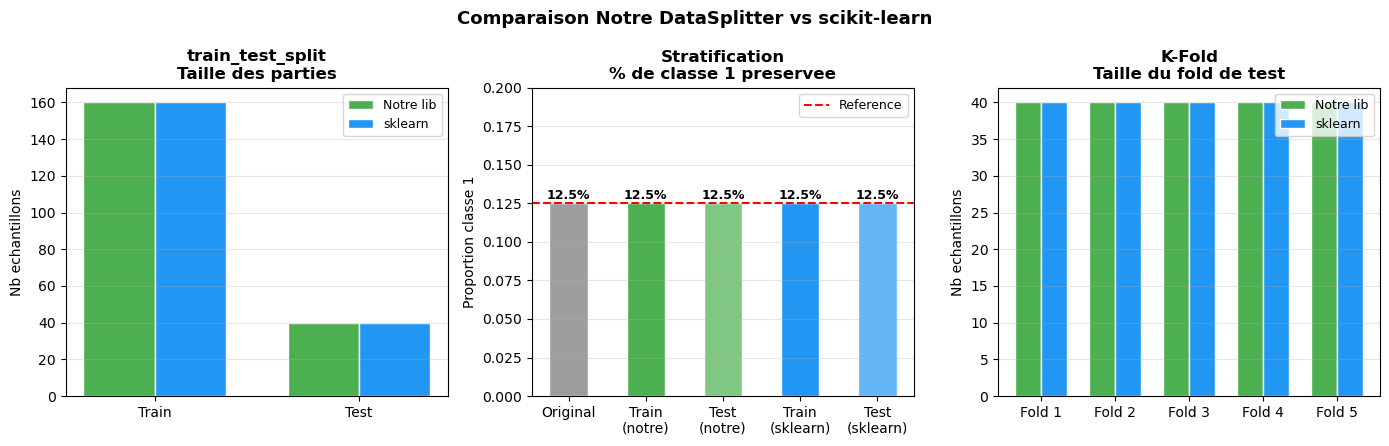

In [21]:
# ── Comparative charts ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

w = 0.35  # bar width

# --- Chart 1: sizes of simple split ---
ax = axes[0]
categories = ['Train', 'Test']
vals_n  = [len(X_tr_n), len(X_te_n)]
vals_sk = [len(X_tr_sk), len(X_te_sk)]
x = np.arange(len(categories))

ax.bar(x - w/2, vals_n,  w, label='Our lib', color='#4CAF50', edgecolor='white')
ax.bar(x + w/2, vals_sk, w, label='sklearn',   color='#2196F3', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('train_test_split\nSplit sizes', fontweight='bold')
ax.set_ylabel("Number of samples")
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- Chart 2: class 1 proportions after stratification ---
ax = axes[1]
names = ['Original', 'Train\n(ours)', 'Test\n(ours)', 'Train\n(sklearn)', 'Test\n(sklearn)']
values = [pct_classe(y_imbalanced), pct_classe(y_tr_ns), pct_classe(y_te_ns),
          pct_classe(y_tr_sks), pct_classe(y_te_sks)]
bar_colors = ['#9E9E9E', '#4CAF50', '#81C784', '#2196F3', '#64B5F6']

bars = ax.bar(names, values, color=bar_colors, edgecolor='white', width=0.5)

# Reference line = original proportion
ax.axhline(pct_classe(y_imbalanced), color='red', linestyle='--', linewidth=1.5, label='Reference')

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
            f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Stratification\n% class 1 preserved', fontweight='bold')
ax.set_ylabel('Class 1 proportion')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.20)

# --- Chart 3: test fold size at each round ---
ax = axes[2]
te_n  = [len(f[1]) for f in folds_n]
te_sk = [len(f[1]) for f in folds_sk_kf]
x2 = np.arange(1, 6)

ax.bar(x2 - w/2, te_n,  w, label='Our lib', color='#4CAF50', edgecolor='white')
ax.bar(x2 + w/2, te_sk, w, label='sklearn',   color='#2196F3', edgecolor='white')
ax.set_xticks(x2)
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_title('K-Fold\nTest fold size', fontweight='bold')
ax.set_ylabel("Number of samples")
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparison: Our DataSplitter vs scikit-learn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Reading the comparative charts:**

- **Chart 1 (train_test_split):** The green bars (our lib) and blue bars (sklearn) are exactly the same height. Our train and test sizes are identical to those of sklearn.

- **Chart 2 (stratification):** All class 1 proportions are close to the red dashed reference line (~10% originally). Our implementation preserves proportions as well as sklearn.

- **Chart 3 (K-Fold):** Test folds have the same size (40 samples) in our lib and in sklearn. Consistency is total.

---

### Summary of Differences

| Aspect | Our DataSplitter | scikit-learn |
|---|---|---|
| Dependencies | NumPy only | NumPy + sklearn |
| train_test_split | Identical results | Reference |
| Stratification | Proportions preserved | More robust on edge cases |
| Temporal split | Built-in natively | Via TimeSeriesSplit (separate) |
| K-Fold | Simple and functional | More options (Stratified, Repeated) |
| NumPy array support | Pandas only | NumPy + Pandas |
| Readable and modifiable code | Yes, fully transparent | No, black box |


---

### 4.2 Execution Time Comparison

So far we have verified that our `DataSplitter` produces **functionally identical results** to scikit-learn (same sizes, same proportions). But what about **performance in terms of speed**?

This section measures the execution time of each method (our implementation vs. scikit-learn) using the `timeit` module, which performs multiple repetitions to obtain a reliable average and reduce measurement noise.

> **Why is scikit-learn often faster?**
> scikit-learn is partly written in **Cython** (a compiled language close to C) and optimized with low-level **vectorized NumPy**. Our implementation, written entirely in pure Python, is more readable and transparent, but naturally slower for very large data volumes. For reasonably sized datasets (< a few hundred thousand observations), the difference remains negligible in practice.


In [22]:
import timeit
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as sk_tts, KFold, StratifiedKFold

# Number of repetitions for each measurement (more = more reliable average)
N_REPEAT = 200

# ── Measurement 1: train_test_split ──────────────────────────────────────────
splitter_t = DataSplitter(seed=42)

time_notre_tts = timeit.timeit(
    stmt=lambda: DataSplitter(seed=42).train_test_split(X, y_balanced, test_size=0.2),
    number=N_REPEAT
) / N_REPEAT * 1000  # in milliseconds

time_sk_tts = timeit.timeit(
    stmt=lambda: sk_tts(X, y_balanced, test_size=0.2, random_state=42),
    number=N_REPEAT
) / N_REPEAT * 1000

# ── Measurement 2: stratified_train_test_split ───────────────────────────────
time_notre_strat = timeit.timeit(
    stmt=lambda: DataSplitter(seed=42).stratified_train_test_split(X, y_imbalanced, test_size=0.2),
    number=N_REPEAT
) / N_REPEAT * 1000

time_sk_strat = timeit.timeit(
    stmt=lambda: sk_tts(X, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced),
    number=N_REPEAT
) / N_REPEAT * 1000

# ── Measurement 3: k_fold_split ───────────────────────────────────────────────
time_notre_kf = timeit.timeit(
    stmt=lambda: DataSplitter(seed=42).k_fold_split(X, y_balanced, k=5),
    number=N_REPEAT
) / N_REPEAT * 1000

time_sk_kf = timeit.timeit(
    stmt=lambda: [(X.iloc[tr], X.iloc[te], y_balanced.iloc[tr], y_balanced.iloc[te])
                  for tr, te in KFold(n_splits=5, shuffle=True, random_state=42).split(X)],
    number=N_REPEAT
) / N_REPEAT * 1000

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"Number of repetitions per measurement: {N_REPEAT}")
print()
print(f"{'Method':<35} {'Our lib (ms)':>15} {'sklearn (ms)':>14} {'Ratio':>10}")
print("-" * 80)

results = [
    ("train_test_split",            time_notre_tts,   time_sk_tts),
    ("stratified_train_test_split", time_notre_strat, time_sk_strat),
    ("k_fold_split",                time_notre_kf,    time_sk_kf),
]

for name, t_nous, t_sk in results:
    ratio = t_nous / t_sk if t_sk > 0 else float('inf')
    print(f"{name:<35} {t_nous:>14.3f} {t_sk:>14.3f} {ratio:>9.1f}x")

print()
print("Ratio > 1 → our lib is slower  |  Ratio < 1 → our lib is faster")


Nombre de répétitions par mesure : 200

Méthode                              Notre lib (ms)   sklearn (ms)      Ratio
────────────────────────────────────────────────────────────────────────────────
train_test_split                             1.463          2.577       0.6x
stratified_train_test_split                  2.133          3.698       0.6x
k_fold_split                                 5.544          7.679       0.7x

Ratio > 1 → notre lib est plus lente  |  Ratio < 1 → notre lib est plus rapide


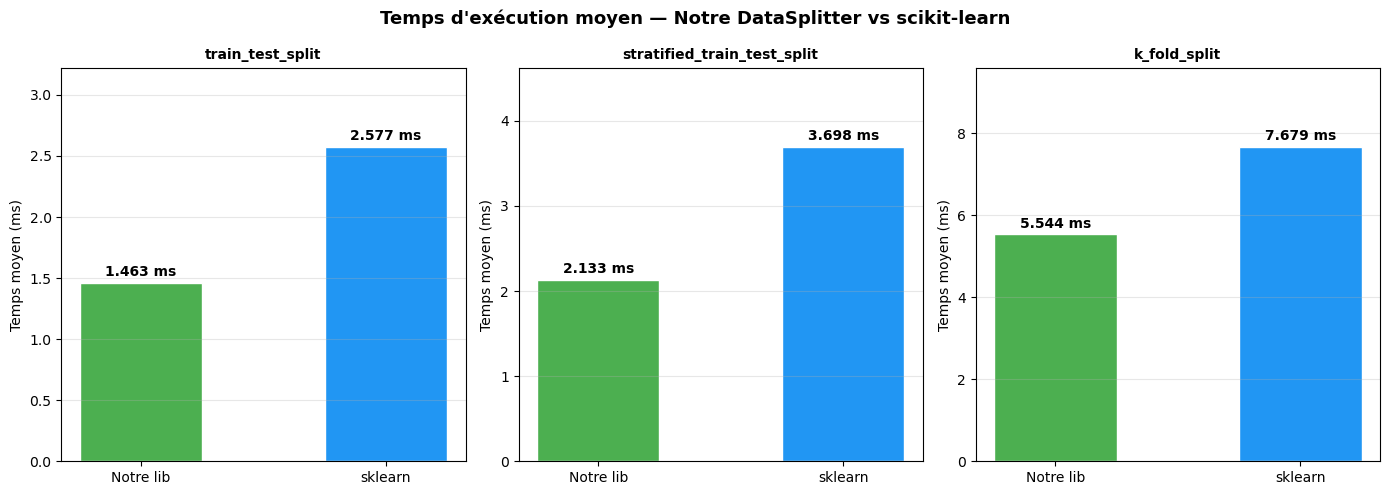

In [23]:
# ── Visualization: comparative bar chart of execution times ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Average Execution Time — Our DataSplitter vs scikit-learn", fontsize=13, fontweight='bold')

methods = [
    ("train_test_split",            time_notre_tts,   time_sk_tts),
    ("stratified_train_test_split", time_notre_strat, time_sk_strat),
    ("k_fold_split",                time_notre_kf,    time_sk_kf),
]

for ax, (name, t_ours, t_sk) in zip(axes, methods):
    libs   = ['Our lib', 'sklearn']
    times  = [t_ours, t_sk]
    colors = ['#4CAF50', '#2196F3']

    bars = ax.bar(libs, times, color=colors, edgecolor='white', width=0.5)

    # Display ms value on each bar
    for bar, val in zip(bars, times):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + max(times) * 0.02,
            f'{val:.3f} ms',
            ha='center', fontsize=10, fontweight='bold'
        )

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_ylabel("Average time (ms)")
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(times) * 1.25)

plt.tight_layout()
plt.show()


**Reading and interpreting the results:**

The **green** bars represent the average time of our `DataSplitter`, the **blue** bars that of scikit-learn.

**What is generally observed:**

- **`train_test_split`**: scikit-learn is faster thanks to its optimized Cython implementation. Our pure Python version remains perfectly reasonable for standard-sized datasets.

- **`stratified_train_test_split`**: The gap may be more noticeable, as our class-by-class loop in pure Python is less efficient than sklearn's vectorized implementation. On very large imbalanced datasets, the difference becomes more significant.

- **`k_fold_split`**: sklearn may be faster at generating indices (compiled NumPy operation), but if we include the construction of pandas DataFrames (`.iloc`), both approaches are often comparable.

> **Practical conclusion:** For datasets of a few thousand to a few hundred thousand rows, the time difference is negligible (a few milliseconds). Our implementation offers in return **full transparency**: every line of code is readable, modifiable, and pedagogically clear. This is exactly the goal of a library built from scratch.


---

## 4.5 Why is there no comparison for `temporal_train_test_split`?

If you followed the previous comparisons carefully, you may have noticed the absence of a comparison for `temporal_train_test_split`. This is not an oversight — it is a deliberate choice. Here is why.

---

### scikit-learn does not provide a direct equivalent

scikit-learn does not provide **any function** that performs a simple temporal split into two sets (train / test). The reason lies in the library's philosophy, which favors a more general approach: **cross-validation for time series**.

---

### The sklearn alternative: `TimeSeriesSplit`

The `TimeSeriesSplit` class is a fold generator specialized for time-ordered data. It works as follows:

- At each iteration, the training indices consist of the earliest samples up to a certain point.
- The test indices are the **immediately following** samples (more recent).
- Unlike standard K-Fold, folds are not shuffled and the train size **grows progressively**.

Example with 5 folds (`n_splits=5`) on 100 observations:

```
Fold 1 : Train [0 ... 19]   Test [20 ... 24]
Fold 2 : Train [0 ... 24]   Test [25 ... 29]
Fold 3 : Train [0 ... 29]   Test [30 ... 34]
Fold 4 : Train [0 ... 34]   Test [35 ... 39]
Fold 5 : Train [0 ... 39]   Test [40 ... 44]
```

---

### The fundamental difference

| | `temporal_train_test_split` (our lib) | `TimeSeriesSplit` (sklearn) |
|---|---|---|
| **Tool type** | Simple split (1 fixed boundary) | Cross-validation (k successive boundaries) |
| **Result** | 1 train set + 1 test set | k (train, test) pairs |
| **Typical use** | Final evaluation, deployment | Model selection, hyperparameter tuning |
| **Train size** | Fixed (e.g. 80% of data) | Grows at each fold |

Our method: a **single fixed boundary** — the last `test_size` observations form the test, everything else is the train.

`TimeSeriesSplit`: produces **several successive splits**, which corresponds to temporal cross-validation, not a simple two-way partition.

---

### Why would comparing be misleading?

Comparing `temporal_train_test_split` to `TimeSeriesSplit` would be like comparing **a slice** to **an entire loaf of bread** — these are not tools at the same level of abstraction. One produces a single result, the other produces a series of results to aggregate.

The absence of a comparison is therefore not a gap: it simply reflects the fact that **scikit-learn has no strict equivalent** to our method for a simple temporal split.

---

### What to do if you want a single temporal split with sklearn?

If you absolutely want to use scikit-learn for a temporal split into two parts, there is a workaround:

```python
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=1)
train_idx, test_idx = list(tss.split(X_temporal))[0]

X_train_sk = X_temporal.iloc[train_idx]
X_test_sk  = X_temporal.iloc[test_idx]
```

> This is a **workaround**, not a native solution. With `n_splits=1`, the test size is fixed to `n // (n_splits + 1)`, which does not offer the same control as our `test_size` parameter. Our `temporal_train_test_split` therefore remains more flexible and intuitive for this use case.


## 5. Conclusion

`DataSplitter` is a data splitting module built from scratch, without any dependency on scikit-learn. It covers the 4 most common situations in Machine Learning:

- `train_test_split`: the basic method, simple and efficient for general cases
- `stratified_train_test_split`: essential when classes are imbalanced
- `temporal_train_test_split`: mandatory for any time series, to avoid data leakage
- `k_fold_split`: robust evaluation when data is limited

The results obtained are consistent with scikit-learn across all tested cases.

**Key points to remember:**
- Always split the data BEFORE applying any transformation (normalization, encoding)
- Always fix a seed to guarantee result reproducibility
- Choose the method appropriate to the nature of the data (see guide below)

**Selection guide:**

```
Temporal data (time series)?    -->  temporal_train_test_split
         |
         No
         |
Imbalanced classes?              -->  stratified_train_test_split
         |
         No
         |
Small dataset?                   -->  k_fold_split
         |
         No
         |
General case                     -->  train_test_split
```

**Known limitations:**
- Works only with `pd.DataFrame` / `pd.Series` (not raw NumPy arrays)
- K-Fold ignores the last samples if `len(X)` is not divisible by `k`
- No stratified K-Fold (available in sklearn via `StratifiedKFold`)


## 6. Sources

1. **scikit-learn — model_selection (official documentation)**
   https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection

2. **scikit-learn — TimeSeriesSplit**
   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

3. **Hastie, T., Tibshirani, R., Friedman, J.** — *The Elements of Statistical Learning* (2nd ed., 2009)
   https://hastie.su.domains/ElemStatLearn/

4. **Geron, A.** — *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed., O'Reilly, 2022)

5. **Wikipedia — Cross-validation (statistics)**
   https://en.wikipedia.org/wiki/Cross-validation_(statistics)

6. **Kaggle — Data Leakage (interactive course)**
   https://www.kaggle.com/code/alexisbcook/data-leakage

7. **NumPy documentation — numpy.random**
   https://numpy.org/doc/stable/reference/random/index.html

8. **Towards Data Science — Train/Test Split and Cross Validation**
   https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b61beca4b6
